# **Time correlators of electric and magnetic Glasma fields, averaged over transverse plane, at various proper times**

Fields correlators of the Glasma $\langle F(\tau)F(\tau+\delta\tau)\rangle$, as a function of proper time difference $\delta\tau$, evaluated starting from a time $\tau$, averaged over the transverse simulation plane where the fields reside. Here $F$ stands for electric $E$ or magnetic $B$ fields.

Import all the necessary modules and packages.

In [5]:
# Set environment variables 
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["GAUGE_GROUP"] = "su3"
os.environ["PRECISION"] = "double"

# Import curraun and other packages
import sys
sys.path.append('../..')

import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False
from curraun.fields_correlators import FieldsCorrelators

from curraun.numba_target import use_cuda, use_numba
if use_cuda:
    from numba import cuda

import numpy as np
import pickle
from tqdm import tqdm

Using CUDA
Using SU(3)
Using double precision
Using double precision


In [7]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326

# Simulation box
L   = 10.0
N   = 1024
DTS = 8
NE  = 5

# Glasma fields
g2mu = 2.0          # g²μ [GeV]
g    = 2.0          # coupling constant
mu   = g2mu / g**2  # MV model parameter [GeV]
ir   = 0.2          # infrared regulator [GeV]
uv   = 10.0         # ultraviolet regulator [GeV]
NS   = 50           # number of color charge sheets

# Derived lattice parameters
a  = L / N
E0 = N / L * hbarc
DT = 1.0 / DTS

# Starting times in dimensionless g²μ·τ units
g2mu_taus = [0.1, 0.2, 0.5, 1.0, 1.5, 2.0]
taus = [x / g2mu * hbarc for x in g2mu_taus]        # proper times [fm/c]
ts   = np.round([t * N / L * DTS for t in taus]).astype(int)

# Maximum time separation to track (dimensionless g²μ·δτ)
g2mu_dtau_max = 3.0
tau_max_steps = int(round(g2mu_dtau_max / g2mu * hbarc * DTS / a))

# Validity checks
cond1_lhs = 2 * np.pi / L * hbarc
print(f"2π/L  = {cond1_lhs:.4f} < m    = {ir}   {'passed' if cond1_lhs < ir  else 'FAILED'}")
cond2_lhs = ir / g2mu
print(f"m/g²μ = {cond2_lhs:.4f} < 1           {'passed' if cond2_lhs < 1   else 'FAILED'}")
cond3_lhs = g2mu * a / hbarc
print(f"g²μ·a = {cond3_lhs:.4f} < 1           {'passed' if cond3_lhs < 1   else 'FAILED'}")
print(f"g²μ·L = {g2mu * L / hbarc:.4f}")
print(f"Starting steps: {ts}")
print(f"Max δτ steps:   {tau_max_steps}")


2π/L  = 0.1240 < m    = 0.2   passed
m/g²μ = 0.1000 < 1           passed
g²μ·a = 0.0990 < 1           passed
g²μ·L = 101.3551
Starting steps: [  8  16  40  81 121 162]
Max δτ steps:   242


Simulation routine for a single event, where all the parameters are stored in a dictionary.

In [8]:
import pickle
from tqdm import tqdm

ET_avg, BT_avg = {}, {}
EL_avg, BL_avg = {}, {}

for i, t_start in enumerate(ts):
    key = str(int(t_start))
    ETs, BTs = [], []
    ELs, BLs = [], []

    with tqdm(total=NE, desc=f'g²μt = {g2mu_taus[i]}') as pbar:
        for e in range(NE):
            s  = core.Simulation(N, DT, g)
            va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=NS)
            vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=NS)
            initial.init(s, va, vb)

            if use_cuda:
                s.copy_to_device()

            fields = FieldsCorrelators(s)
            E_ref, B_ref = None, None

            ET_e = np.zeros(tau_max_steps)
            BT_e = np.zeros(tau_max_steps)
            EL_e = np.zeros(tau_max_steps)
            BL_e = np.zeros(tau_max_steps)

            for step in range(int(t_start) + tau_max_steps + 1):
                core.evolve_leapfrog(s)

                if step == int(t_start):
                    E_ref = fields.compute_elfield()
                    B_ref = fields.compute_magfield()
                elif step > int(t_start):
                    delta_idx = step - int(t_start) - 1
                    EE = fields.compute_elcorr(E_ref)
                    BB = fields.compute_magcorr(B_ref)
                    ET_e[delta_idx] = (EE[0] + EE[1]) * E0**4
                    BT_e[delta_idx] = (BB[0] + BB[1]) * E0**4
                    EL_e[delta_idx] = EE[2] * E0**4
                    BL_e[delta_idx] = BB[2] * E0**4

            ETs.append(ET_e)
            BTs.append(BT_e)
            ELs.append(EL_e)
            BLs.append(BL_e)

            pbar.update(1)

    ET_avg[key] = np.mean(ETs, axis=0)
    BT_avg[key] = np.mean(BTs, axis=0)
    EL_avg[key] = np.mean(ELs, axis=0)
    BL_avg[key] = np.mean(BLs, axis=0)

# delta_tau axis (same for all starting times), following original convention
delta_tau = np.array([j * DT * a for j in range(tau_max_steps)])  # [fm/c]

res = {}
res["ET"], res["BT"] = ET_avg, BT_avg
res["EL"], res["BL"] = EL_avg, BL_avg
res["delta_tau"] = delta_tau
res["ts"], res["taus"] = ts, taus
res["g2mu_taus"] = g2mu_taus
res["g2mu"], res["g"] = g2mu, g
res["E0"], res["hbarc"] = E0, hbarc

fname = "time_corr_glasma.pickle"
pickle.dump(res, open(fname, "wb"))


g²μt = 2.0: 100%|██████████| 5/5 [13:05<00:00, 157.03s/it]


Running the simulation for multiple events and various values of formation times.

*(Superseded — simulation and save are now in the cell above.)*

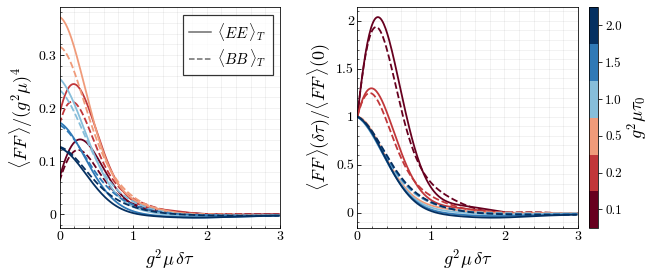

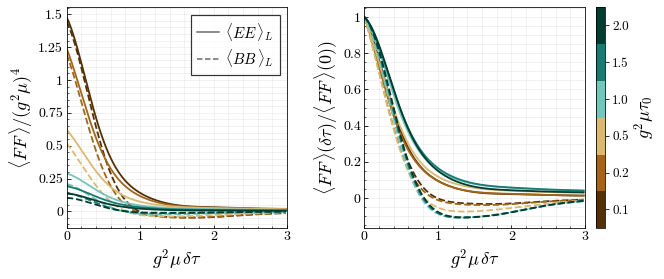

In [9]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

# Load results
fname = "time_corr_glasma.pickle"
res = pickle.load(open(fname, "rb"))

ET_avg    = res["ET"]
BT_avg    = res["BT"]
EL_avg    = res["EL"]
BL_avg    = res["BL"]
delta_tau = res["delta_tau"]   # δτ axis [fm/c], shared by all starting times
g2mu      = res["g2mu"]
g         = res["g"]
E0        = res["E0"]
hbarc     = res["hbarc"]
ts        = res["ts"]
taus      = res["taus"]
g2mu_taus = res["g2mu_taus"]

n = len(ts)
tau_labels = [str(x) for x in g2mu_taus]


def _make_colors(cmap_name, n, skip_inner=2):
    n_total = n + skip_inner
    cmap_d  = cm.get_cmap(cmap_name, n_total)
    all_c   = [cmap_d(i) for i in range(n_total)]
    half    = n_total // 2
    return all_c[: half - skip_inner // 2] + all_c[half + skip_inner // 2 :]


def _fmt_ax(ax, xlabel=None, ylabel=None, xlims=None, fontsize=14):
    if xlims:
        ax.set_xlim(*xlims)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.set_box_aspect(1)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=fontsize + 4)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize + 4)


def _make_fig(cmap_name, plot_fn_abs, plot_fn_norm, cbar_label):
    colors = _make_colors(cmap_name, n)

    fig, (ax_abs, ax_norm) = plt.subplots(1, 2, figsize=(10, 4.5))
    fig.subplots_adjust(left=0.10, right=0.82, bottom=0.14, top=0.95, wspace=0.35)

    plot_fn_abs(ax_abs, colors)
    plot_fn_norm(ax_norm, colors)

    leg = ax_abs.legend(handles=[
        Line2D([0], [0], color='dimgray', linewidth=1.5, linestyle='-',
               label=plot_fn_norm._ee_label),
        Line2D([0], [0], color='dimgray', linewidth=1.5, linestyle='--',
               label=plot_fn_norm._bb_label),
    ], fontsize=15, frameon=True, loc='upper right',
       facecolor='white', edgecolor='black',
       handlelength=1.5, borderpad=0.4, shadow=False,
       handletextpad=0.4, labelspacing=0.3)
    frame = leg.get_frame()
    frame.set_linewidth(1.2)
    frame.set_boxstyle('square', pad=0)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = ax_norm.get_window_extent(renderer).transformed(fig.transFigure.inverted())

    cbar_ax = fig.add_axes([bbox.x1 + 0.016, bbox.y0, 0.012, bbox.height])

    cmap_disc = ListedColormap(colors)
    norm_disc = BoundaryNorm(np.arange(0.5, n + 1.5), cmap_disc.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_disc, norm=norm_disc)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(cbar_label, fontsize=18)
    cbar.set_ticks(np.arange(1, n + 1))
    cbar.set_ticklabels(tau_labels)
    cbar.ax.tick_params(labelsize=13)

    return fig


# shared x-axis (dimensionless)
x = delta_tau * g2mu / hbarc

# ============================================================
# Figure 1: Transverse correlators  (RdBu)
# ============================================================
def _plot_T_abs(ax, colors):
    for i, t in enumerate(ts):
        key = str(int(t))
        ax.plot(x, ET_avg[key] / g2mu**4, color=colors[i], linewidth=1.8)
        ax.plot(x, BT_avg[key] / g2mu**4, color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\,\delta\tau$',
            ylabel=r'$\langle FF\,\rangle/(g^2\mu)^4$',
            xlims=(0, 3))

def _plot_T_norm(ax, colors):
    for i, t in enumerate(ts):
        key = str(int(t))
        ax.plot(x, ET_avg[key] / ET_avg[key][0], color=colors[i], linewidth=1.8)
        ax.plot(x, BT_avg[key] / BT_avg[key][0], color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\,\delta\tau$',
            ylabel=r'$\langle FF\,\rangle(\delta\tau)/\langle FF\,\rangle(0)$',
            xlims=(0, 3))
_plot_T_norm._ee_label = r'$\langle EE\,\rangle_T$'
_plot_T_norm._bb_label = r'$\langle BB\,\rangle_T$'

fig_T = _make_fig('RdBu', _plot_T_abs, _plot_T_norm, r'$g^2\mu\tau_0$')
fig_T.savefig("trans_corr_time.pdf", bbox_inches='tight')
fig_T.savefig("trans_corr_time.png", bbox_inches='tight', dpi=200)
plt.show()


# ============================================================
# Figure 2: Longitudinal correlators  (BrBG)
# ============================================================
def _plot_L_abs(ax, colors):
    for i, t in enumerate(ts):
        key = str(int(t))
        ax.plot(x, EL_avg[key] / g2mu**4, color=colors[i], linewidth=1.8)
        ax.plot(x, BL_avg[key] / g2mu**4, color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\,\delta\tau$',
            ylabel=r'$\langle FF\,\rangle/(g^2\mu)^4$',
            xlims=(0, 3))

def _plot_L_norm(ax, colors):
    for i, t in enumerate(ts):
        key = str(int(t))
        ax.plot(x, EL_avg[key] / EL_avg[key][0], color=colors[i], linewidth=1.8)
        ax.plot(x, BL_avg[key] / BL_avg[key][0], color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\,\delta\tau$',
            ylabel=r'$\langle FF\,\rangle(\delta\tau)/\langle FF\,\rangle(0))$',
            xlims=(0, 3))
_plot_L_norm._ee_label = r'$\langle EE\,\rangle_L$'
_plot_L_norm._bb_label = r'$\langle BB\,\rangle_L$'

fig_L = _make_fig('BrBG', _plot_L_abs, _plot_L_norm, r'$g^2\mu\tau_0$')
fig_L.savefig("long_corr_time.pdf", bbox_inches='tight')
fig_L.savefig("long_corr_time.png", bbox_inches='tight', dpi=200)
plt.show()


## Read data from files using Julia

In [ ]:
using Pickle

res = Pickle.npyload("results/time_corr_glasma.pickle")
tau, elcorr, magcorr = res["tau"], res["elcorr"], res["magcorr"]
Qs, hbarc = res["Qs"], res["hbarc"]
taus = res["taus"]

6-element Vector{Any}:
 0.01
 0.02
 0.05
 0.1
 0.3
 0.5

## Plot results using Makie from Julia

In [ ]:
function string_as_varname(s::AbstractString,v::Any)
    s=Symbol(s)
    return @eval (($s) = ($v))
end

string_as_varname (generic function with 1 method)

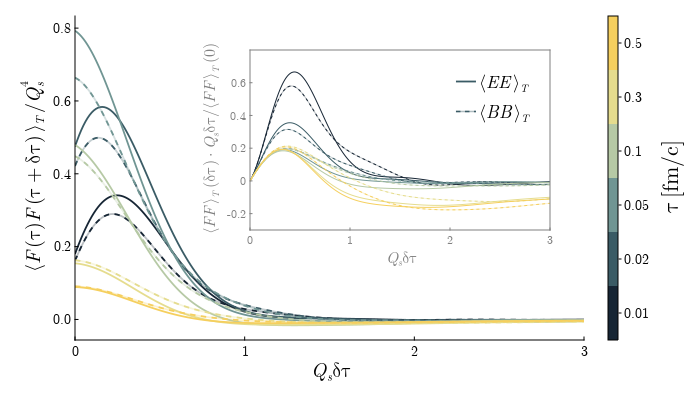

In [ ]:
using CairoMakie
using ColorSchemes

colormap = cgrad(:starrynight, 6, categorical = true)
colors = [colormap[1], colormap[2], colormap[3], colormap[4], colormap[5], colormap[6]]

fig = Figure(resolution = (700, 400), font = "CMU Serif")
ax = Axis(fig[1,1], xlabel=L"Q_s \delta\tau", ylabel=L"\langle F\,(\tau)F\,(\tau+\delta\tau)\,\rangle_T\,/Q_s^4",
        rightspinevisible = false, topspinevisible = false, xlabelsize = 20, ylabelsize= 20, xticklabelsize=14, yticklabelsize=14,
        xtickalign = 1, xticksize=4, ytickalign=1, yticksize=4,  xlabelpadding = -5, xgridvisible = false, ygridvisible = false) 

for (i, itau) in enumerate(taus)
        elcorr_tau, magcorr_tau = elcorr[string(itau)]/Qs^4, magcorr[string(itau)]/Qs^4
        τ = tau[string(itau)]*Qs/hbarc

        elcorr_tau_T = elcorr_tau[:, 1] + elcorr_tau[:, 2]
        string_as_varname("line_el_"*string(i), lines!(ax, τ, elcorr_tau_T, linewidth = 1.8, color=colors[i]))
        lines!(ax, τ, magcorr_tau[:, 1] + magcorr_tau[:, 2], linewidth = 1.8, color=(colors[i], 0.3))
        lines!(ax, τ, magcorr_tau[:, 1] + magcorr_tau[:, 2], linewidth = 1.8, color=colors[i], linestyle="-")
end

xlims!(ax, 0, 3)
# ax.xticks = (1*(0:4), ["0", "1", "2", "3", "4"])
# ylims!(ax, -0.005, 0.2)
# ax.yticks = ([0, 0.1, 0.2], ["0", "0.1", "0.2"])

cbar = Colorbar(fig[1, 2], limits = (0, 6), colormap =  colormap = cgrad(:starrynight, 6, categorical = true), size = 25, labelsize = 22, width = 10, flipaxis = true,
ticksize=3, tickalign = 0, ticklabelsize = 14, height = Relative(1), label=L"\tau\,\mathrm{[fm/c]}")
cbar.ticks = ([0.5, 1.5, 2.5, 3.5, 4.5, 5.5],  ["0.01", "0.02", "0.05", "0.1", "0.3", "0.5"])

ax_inset = Axis(fig, bbox = BBox(250, 550, 170, 350), 
        xlabel=L"Q_s \delta\tau", ylabel=L"\langle FF\,\rangle_T\,(\delta\tau)\cdot Q_s\delta\tau/\langle FF\,\rangle_T\,(0)",
        xlabelsize = 16, ylabelsize= 16, xticklabelsize=12, yticklabelsize=12,
        xtickalign = 1, xticksize=3, ytickalign=1, yticksize=3, xlabelpadding = -2, xgridvisible = false, ygridvisible = false,
        ytickcolor = :grey, xtickcolor = :grey, yticklabelcolor = :grey, xticklabelcolor = :grey, ylabelcolor = :grey, xlabelcolor = :grey,
        bottomspinecolor = :grey, topspinecolor = :grey, leftspinecolor = :grey, rightspinecolor = :grey)

for (i, itau) in enumerate(taus)
        elcorr_tau, magcorr_tau = elcorr[string(itau)], magcorr[string(itau)]
        τ = tau[string(itau)]*Qs/hbarc

        lines!(ax_inset, τ, τ.*(elcorr_tau[:, 1] + elcorr_tau[:, 2])./(elcorr_tau[1, 1] + elcorr_tau[1, 2]), linewidth = 1, color=colors[i])
        lines!(ax_inset, τ, τ.*(magcorr_tau[:, 1] + magcorr_tau[:, 2])./(magcorr_tau[1, 1] + magcorr_tau[1, 2]), linewidth = 1, color=(colors[i], 0.3))
        lines!(ax_inset, τ, τ.*(magcorr_tau[:, 1] + magcorr_tau[:, 2])./(magcorr_tau[1, 1] + magcorr_tau[1, 2]), linewidth = 1, color=colors[i], linestyle="-")
end

xlims!(ax_inset, 0, 3)
# ax_inset.xticks = (1*(0:4), ["0", "1", "2", "3", "4"])
ylims!(ax_inset, -0.3, 0.8)
ax_inset.yticks = ([-0.2, 0, 0.2, 0.4, 0.6], ["-0.2", "0", "0.2", "0.4", "0.6"])

mag = [LineElement(color = colors[2], linestyle = "-", linewidth = 1.5), LineElement(color = (colors[2], 0.4), linewidth = 1.5)]

axislegend(ax_inset, [line_el_2, mag], [L"\langle EE\,\rangle_T", L"\langle BB\,\rangle_T"],  labelsize=18, 
    position = :rt, bgcolor = (:white, 0.7), framecolor = (:white, 0))

display(fig)

# save("plots/time_corr_FF_T.png", fig, px_per_unit = 5.0) 

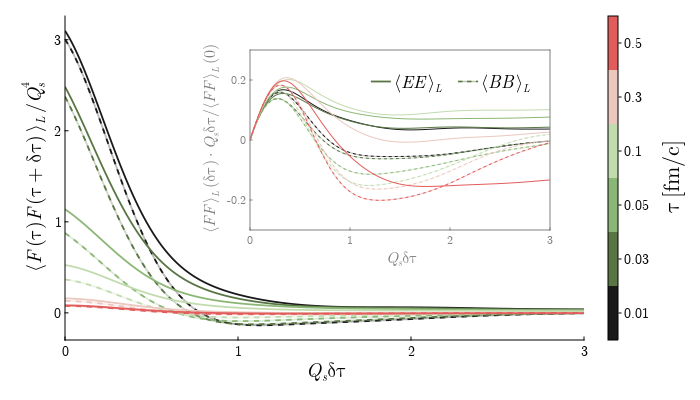

In [ ]:
using CairoMakie
using ColorSchemes

colormap = cgrad(:watermelon, 6, categorical = true)
colors = [colormap[1], colormap[2], colormap[3], colormap[4], colormap[5], colormap[6]]

fig = Figure(resolution = (700, 400), font = "CMU Serif")
ax = Axis(fig[1,1], xlabel=L"Q_s \delta\tau", ylabel=L"\langle F\,(\tau)F\,(\tau+\delta\tau)\,\rangle_L\,/Q_s^4",
        rightspinevisible = false, topspinevisible = false, xlabelsize = 20, ylabelsize= 20, xticklabelsize=14, yticklabelsize=14,
        xtickalign = 1, xticksize=4, ytickalign=1, yticksize=4,  xlabelpadding = -5, xgridvisible = false, ygridvisible = false) 

for (i, itau) in enumerate(taus)
        elcorr_tau, magcorr_tau = elcorr[string(itau)]/Qs^4, magcorr[string(itau)]/Qs^4
        τ = tau[string(itau)]*Qs/hbarc

        string_as_varname("line_el_"*string(i), lines!(ax, τ, elcorr_tau[:, 3], linewidth = 1.8, color=colors[i]))
        lines!(ax, τ, magcorr_tau[:, 3], linewidth = 1.8, color=(colors[i], 0.3))
        lines!(ax, τ, magcorr_tau[:, 3], linewidth = 1.8, color=colors[i], linestyle="-")
end

xlims!(ax, 0, 3)
# ax.xticks = (1*(0:4), ["0", "1", "2", "3", "4"])
# ylims!(ax, -0.02, 0.22)
# ax.yticks = ([0, 0.2, 0.4, 0.6, 0.8], ["0", "0.2", "0.4", "0.6", "0.8"])

cbar = Colorbar(fig[1, 2], limits = (0, 6), colormap =  colormap = cgrad(:watermelon, 6, categorical = true), size = 25, labelsize = 22, width = 10, flipaxis = true,
ticksize=3, tickalign = 0, ticklabelsize = 14, height = Relative(1), label=L"\tau\,\mathrm{[fm/c]}")
cbar.ticks = ([0.5, 1.5, 2.5, 3.5, 4.5, 5.5],  ["0.01", "0.03", "0.05", "0.1", "0.3", "0.5"])

ax_inset = Axis(fig, bbox = BBox(250, 550, 170, 350), 
        xlabel=L"Q_s \delta\tau", ylabel=L"\langle FF\,\rangle_L\,(\delta\tau)\cdot Q_s\delta\tau/\langle FF\,\rangle_L\,(0)",
        xlabelsize = 16, ylabelsize= 16, xticklabelsize=12, yticklabelsize=12,
        xtickalign = 1, xticksize=3, ytickalign=1, yticksize=3, xlabelpadding = -2, xgridvisible = false, ygridvisible = false,
        ytickcolor = :grey, xtickcolor = :grey, yticklabelcolor = :grey, xticklabelcolor = :grey, ylabelcolor = :grey, xlabelcolor = :grey,
        bottomspinecolor = :grey, topspinecolor = :grey, leftspinecolor = :grey, rightspinecolor = :grey)

for (i, itau) in enumerate(taus)
        elcorr_tau, magcorr_tau = elcorr[string(itau)], magcorr[string(itau)]
        τ = tau[string(itau)]*Qs/hbarc

        lines!(ax_inset, τ, τ.*elcorr_tau[:, 3]./elcorr_tau[1, 3], linewidth = 1, color=colors[i])
        lines!(ax_inset, τ, τ.*magcorr_tau[:, 3]./magcorr_tau[1, 3], linewidth = 1, color=(colors[i], 0.3))
        lines!(ax_inset, τ, τ.*magcorr_tau[:, 3]./magcorr_tau[1, 3], linewidth = 1, color=colors[i], linestyle="-")
end

xlims!(ax_inset, 0, 3)
# ax_inset.xticks = (1*(0:4), ["0", "1", "2", "3", "4"])
ylims!(ax_inset, -0.3, 0.3)
ax_inset.yticks = ([-0.2, 0, 0.2, 0.4], ["-0.2", "0", "0.2", "0.4"])

mag = [LineElement(color = colors[2], linestyle = "-", linewidth = 1.5), LineElement(color = (colors[2], 0.4), linewidth = 1.5)]

axislegend(ax_inset, [line_el_2, mag], [L"\langle EE\,\rangle_L", L"\langle BB\,\rangle_L"],  labelsize=18, 
    position = :rt, bgcolor = (:white, 0.7), framecolor = (:white, 0), orientation=:horizontal)

display(fig)

# save("plots/time_corr_FF_L.png", fig, px_per_unit = 5.0) 